In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import timeit
import scipy.stats as stats
import pandas as pd
%matplotlib inline

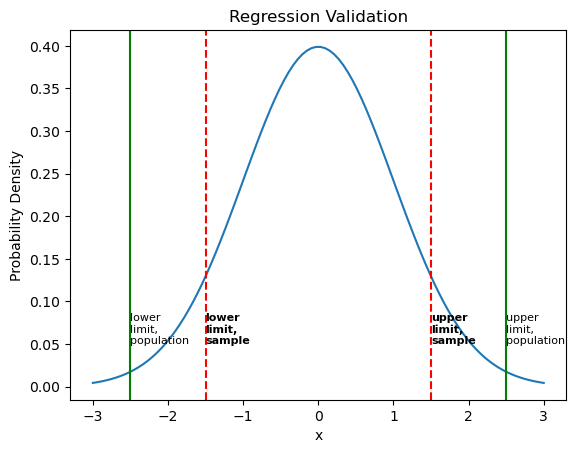

In [2]:
# Generate random numbers from a normal distribution
mu = 0  # mean
sigma = 1  # standard deviation
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = stats.norm.pdf(x, mu, sigma)

# Plot the normal distribution curve
plt.plot(x, y)
plt.title("Regression Validation")
plt.xlabel("x")
plt.ylabel("Probability Density")

plt.axvline(x=1.5, color='r', linestyle='--')
plt.axvline(x=-1.5, color='r', linestyle='--')
plt.axvline(x=2.5, color='g', linestyle='-')
plt.axvline(x=-2.5, color='g', linestyle='-')
plt.text(2.5,.05,'upper\nlimit,\npopulation',fontsize=8)
plt.text(1.5,.05,'upper\nlimit,\nsample',fontsize=8, fontweight ='bold')
plt.text(-2.5,.05,'lower\nlimit,\npopulation',fontsize=8)
plt.text(-1.5,.05,'lower\nlimit,\nsample',fontsize=8, fontweight ='bold')

#plt.savefig('Regression_Validation.png')
plt.show()

In [18]:
df = pd.read_csv("https://gitlab.com/adomakor412/sheardata/-/raw/main/preliminary_162x127.csv")
df

,1,2,3,4,5,6,7,8,9,10,...,120,121,122,123,124,125,126,127,Unnamed: 127,Unnamed: 128
0,NaN,Nr.,Lit.,Bez.,Einheiten E,Querschnittswerte - Section properties,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,b\nb,bw\nbw,h\nh,hf\nhf,"hh,top\nhh,top",...,f´c\nfc_prime,Vct_ACI,Vs_ACI,Vcal_sACI,Vmax_ACI,rat_smax,VACI_cal,gmod_ACI,NaN,NaN
2,NaN,Nr.,Lit.,Bez.,E,NaN,NaN,NaN,NaN,NaN,...,f´c\nfc_prime,Vct_ACI,Vs_ACI,Vcal_sACI,Vmax_ACI,rat_smax,VACI_cal,gmod_ACI,NaN,NaN
3,NaN,-,-,-,SI / A,mm,mm,mm,mm,mm,...,MPa,kN,kN,kN,kN,NaN,kN,NaN,NaN,NaN
4,Ahmad_1996_003_NNW-3,19,Ahmad; Xie; Yu (1996),NNW-3,A,"127,0","127,0","254,0",NaN,NaN,...,"39,1","26,82","41,06","67,88","134,08","0,506","67,88","1,286",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,Rosenbusch_2003_002_1.4-1,817,Rosenbusch (2003),1.4/1,SI,"200,0","200,0","300,0",NaN,NaN,...,"45,5","58,26","49,37","107,63","291,28","0,369","107,63","1,585",NaN,NaN
157,Rosenbusch_2003_004_1.7-1,819,Rosenbusch (2003),1.7/1,SI,"200,0","200,0","300,0",NaN,NaN,...,"48,0","59,82","159,73","219,55","299,09","0,734","219,55","0,867",NaN,NaN
158,Kautsch_2010_001_A2,820,Kautsch (2010),A2,SI,"655,0","155,0","820,0","150,0","20,0",...,"28,4","98,76","291,68","390,44","493,81","0,791","390,44","1,683",NaN,NaN
159,Kautsch_2010_002_B2,821,Kautsch (2010),B2,SI,"655,0","155,0","820,0","150,0","20,0",...,"29,0","99,73","218,76","318,49","498,65","0,639","318,49","1,794",NaN,NaN


In [19]:
data = pd.read_csv("dataDropped_from_162by127_to_157rowsby84columns.csv", sep=";")
dfexp = data[data.columns[1:]]
dfexp.index = range(4, 161)
dfexp

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [20]:
df_Target = dfexp[dfexp['76'] >= dfexp['126']]
listTargetIndex = list(df_Target.index)
listTargetIndex

[4,
 5,
 6,
 7,
 8,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 158,
 159]

In [21]:
len(listTargetIndex)

151

In [22]:
top20FeaturesNo = ["94","92","72","8","26","25","96","97","123","15","88","60","118","119","120","117","62","67","66","124"]
top20Features = ["z",#94
                 "z_test",#92
                 "V_g",#72
                 "h",#8
                 "d",#26
                 "d_s",#25
                 "M_u,flex",#96
                 "V_u,flex",#97
                 "V_cal_s,ACI",#123
                 "A_c",#15
                 "K_c",#88
                 "f_1c",#60
                 "f_cm,cyl",#118
                 "f_ck",#119
                 "f'c",#120
                 "f_1ck",#117
                 "f_cwu",#62
                 "B_ct,cal",#67
                 "f_1ct,m,cal",#66
                 "Vmax_ACI" #124
                ]

In [ ]:
#For loop to iterate over curve